In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tensorflow as tf
import random

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

# !pip install tensorflow==2.15

In [2]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, GlobalAveragePooling1D, Dense, Input, Dropout, Concatenate, GlobalMaxPooling1D, LayerNormalization, Masking, GRU
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

# 1. Load Data

In [ ]:
df = pd.read_csv('YOUR FILE.csv')
grouped_df = df.groupby('API_UWI')
print(grouped_df.ngroups)
df.columns

3057


Index(['API_UWI', 'County', 'ENVInterval', 'WellPadDirection', 'ENVOperator',
       'Latitude', 'Longitude', 'TVD_FT', 'MD_FT', 'ElevationGL_FT',
       'CompletionTime_DAYS', 'LateralLength_FT', 'FracStages',
       'AverageStageSpacing_FT', 'GasGravity_SG', 'TopOfZone_FT',
       'BottomOfZone_FT', 'SubseaTopDepth_FT', 'SubseaBaseDepth_FT',
       'Isopach_FT', 'GammaRay_API', 'BulkDensity_GPerCC', 'Resistivity_OHMSM',
       'DensityPorosity_PCT', 'EffectivePorosity_PCT', 'ClayVolume_PCT',
       'NonClayVolume_PCT', 'WaterSaturation_PCT', 'PhiH_FT', 'HCPV_PCT',
       'HeightOfHCPV_FT', 'TotalOrganicCarbon_WTPCT', 'MontneyClass',
       'Longitude_mid', 'Latitude_mid', 'ProducingMonth', 'TotalProdMonths',
       'CDLiquids_BBLPerDAY', 'CDGas_MCFPerDAY', 'CDWater_BBLPerDAY',
       'PeakTime', 'PeakRate', 'StartYear', 'Year', 'Month', 'ShutIns',
       'DenoisedGasRate', 'Di', 'b'],
      dtype='object')

In [6]:
def to_length(train_df,set_len,name,static_feature_list_num):
  pad_well = train_df.copy()
  org_len = len(pad_well)
  if org_len < set_len:
      padding_rows = set_len - org_len
      nan_padding = pd.DataFrame(np.nan, index=np.arange(padding_rows), columns=pad_well.columns)
      pad_well = pd.concat([pad_well, nan_padding], ignore_index=True)
      static_features = pad_well[static_feature_list_num].iloc[0].to_dict()

      for feature in static_feature_list_num:
            pad_well.loc[org_len:set_len-1, feature] = static_features[feature]

      # Special care to the four parameters in the dataframe ['TotalProdMonths', 'Year', 'Month', 'ShutIns']
      for i in range(padding_rows):
          pad_well.at[len(train_df) + i, 'TotalProdMonths'] = pad_well['TotalProdMonths'].iloc[len(train_df) - 1] + i + 1

      producing_month = pd.to_datetime(pad_well['ProducingMonth'].iloc[0])
      for i in range(padding_rows):
          future_month = producing_month + pd.DateOffset(months=len(train_df) + i)
          pad_well.at[len(train_df) + i, 'Year'] = future_month.year
          pad_well.at[len(train_df) + i, 'Month'] = future_month.month
          pad_well.at[len(train_df) + i, 'ShutIns'] = 0
          pad_well.at[len(train_df) + i, 'API_UWI'] = name

  return pad_well

In [7]:
static_feature_list_num = ['Latitude', 'Longitude', 'TVD_FT', 'MD_FT', 'ElevationGL_FT',
       'CompletionTime_DAYS', 'LateralLength_FT', 'FracStages',
       'AverageStageSpacing_FT', 'GasGravity_SG', 'TopOfZone_FT',
       'BottomOfZone_FT', 'SubseaTopDepth_FT', 'SubseaBaseDepth_FT',
       'Isopach_FT', 'GammaRay_API', 'BulkDensity_GPerCC', 'Resistivity_OHMSM',
       'DensityPorosity_PCT', 'EffectivePorosity_PCT', 'ClayVolume_PCT',
       'NonClayVolume_PCT', 'WaterSaturation_PCT', 'PhiH_FT', 'HCPV_PCT',
       'HeightOfHCPV_FT', 'TotalOrganicCarbon_WTPCT', 'Longitude_mid', 'Latitude_mid', 'StartYear']
static_feature_list_class = ['County', 'ENVInterval', 'WellPadDirection', 'ENVOperator']
static_feature_list = static_feature_list_class+static_feature_list_num
grouped_df = df.groupby('API_UWI')
df_extend  = []
for name, group in grouped_df:
    extended = to_length(group,72,name,static_feature_list)
    df_extend.append(extended)
df_extend = pd.concat(df_extend,axis=0).reset_index(drop=True)
grouped_df_ex = df_extend.groupby('API_UWI')

In [8]:
# split for training and testing
split_year = 2021
training_samples = []
testing_samples = []

for name, group in grouped_df_ex:
    train_sample = group[group['StartYear'] < split_year]
    test_sample = group[group['StartYear'] >= split_year]

    training_samples.append(train_sample)
    testing_samples.append(test_sample)

training_data = pd.concat(training_samples)
testing_data = pd.concat(testing_samples)

training_data = training_data.reset_index(drop=True)
testing_data = testing_data.reset_index(drop=True)

grouped_train = training_data.groupby('API_UWI')
grouped_test = testing_data.groupby('API_UWI')

In [9]:
dynamic_feature_list = ['TotalProdMonths', 'Year', 'Month', 'ShutIns']
ARterms_list = ['CDLiquids_BBLPerDAY', 'CDGas_MCFPerDAY', 'CDWater_BBLPerDAY']
out_list = ['DenoisedGasRate']

all_columns_to_normalize = static_feature_list_num + dynamic_feature_list + ARterms_list+ out_list
DU_list =  dynamic_feature_list + ARterms_list
DS_list = static_feature_list + dynamic_feature_list

# Normalization
scaler = MinMaxScaler()
training_data_norm = training_data.copy()
training_data_norm[all_columns_to_normalize] = scaler.fit_transform(training_data[all_columns_to_normalize])
training_data_norm[all_columns_to_normalize] = np.log(training_data_norm[all_columns_to_normalize]+1)

testing_data_norm = testing_data.copy()
testing_data_norm[all_columns_to_normalize] = scaler.transform(testing_data[all_columns_to_normalize])
testing_data_norm[all_columns_to_normalize] = np.log(testing_data_norm[all_columns_to_normalize]+1)

# Group by 'API_UWI' for further processing
grouped_train_norm = training_data_norm.groupby('API_UWI')
grouped_test_norm = testing_data_norm.groupby('API_UWI')

# 2. ST-GFE: Approach 1, by the wellhead location
## 2.1 Form the Graph

In [ ]:
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist

In [ ]:
loc_info = []
for name, group in grouped_train:
  group = group.reset_index(drop=True)
  well_loc = np.array(group[['Longitude','Latitude']].iloc[0])
  loc_info.append(well_loc)
loc_info = np.array(loc_info)

clustering = DBSCAN(eps=0.001,min_samples=1).fit(loc_info)
cluster_labels = clustering.labels_

In [ ]:
def trim_hist(sequence, max_len, pad_value = -1e9):
    num_features = sequence.shape[1]
    if len(sequence) > max_len:
        trimmed_sequence = sequence[-max_len:]
    else:
        padding = np.zeros((max_len - len(sequence), num_features))+pad_value
        trimmed_sequence = np.vstack((padding, sequence))
    return trimmed_sequence

def trim_future(sequence, max_len, pad_value = -1e9):
    num_features = sequence.shape[1]
    if len(sequence) > max_len:
        trimmed_sequence = sequence[:max_len]
    else:
        padding = np.zeros((max_len - len(sequence), num_features))+pad_value
        trimmed_sequence = np.vstack((sequence, padding))
    return trimmed_sequence

def min_max_normalize(dist_matrix, max_dist):
    return (dist_matrix - 0)/ (max_dist - 0)

def distance_to_adjacency(normalized_dist_matrix):
  return 1 - normalized_dist_matrix

def create_dynamic_adj_matrix(adj_matrix, dynamic_data, pad_value):
    num_nodes, num_sequence, num_features = dynamic_data.shape
    # Initialize the result matrix with shape [node, sequence, node]
    dynamic_adj_matrix = np.tile(adj_matrix, (num_sequence, 1, 1)).transpose(1, 0, 2)

    for t in range(num_sequence):
        for n in range(num_nodes):
            mask_value = dynamic_data[n, t, -1]  # Use the the last feature as the mask_value; water rate
            if mask_value == pad_value:
                dynamic_adj_matrix[n, t, :] = 0
                dynamic_adj_matrix[:, t, n] = 0

    return dynamic_adj_matrix

In [ ]:
gfe_static_inputs = []
gfe_dynamic_inputs = []
adj_matrix = []
start_dates = []
max_distance = 0.005  # The maximum distance threshold
max_len = 36
pad_value = -999

for well_i in range(len(cluster_labels)):
# for well_i in range(20):
    # Find wells in the same cluster
    cluster_wells = np.where(cluster_labels == cluster_labels[well_i])[0]
    well_names = [list(grouped_train.groups.keys())[i] for i in cluster_wells]

    gfe_static_input = []
    gfe_dynamic_input = []
    well_locs = []
    name_ii = list(grouped_train_norm.groups.keys())[well_i]
    #print(f"Studied: {name_ii}")
    df_well = grouped_train.get_group(name_ii).reset_index(drop=True)
    df_well_norm = grouped_train_norm.get_group(name_ii).reset_index(drop=True)
    gfe_output = np.array(df_well_norm[out_list])

    # Find the starting time of the studied well
    start_year = int(df_well['Year'][0])
    start_month = int(df_well['Month'][0])
    start_date = pd.Timestamp(year=start_year, month=start_month, day=1)
    start_dates.append([start_year, start_month])

    for name_i in well_names:
        #print(f"neighbor: {name_i}")
        df_well = grouped_train.get_group(name_i).reset_index(drop=True)
        df_well_norm = grouped_train_norm.get_group(name_i).reset_index(drop=True)
        input_static_norm = np.array(df_well_norm[static_feature_list].iloc[0])

        # Find the starting time of the neighboring well
        start_year_adj = int(df_well['Year'][0])
        start_month_adj = int(df_well['Month'][0])
        start_date_adj = pd.Timestamp(year=start_year_adj, month=start_month_adj, day=1)

        df_sequence = df_well_norm[DU_list]

        if start_date_adj <= start_date:
            # Sequentially search the starting month of the neighboring wells
            for time_i in range(len(df_well)):
                if df_well['Year'][time_i] == start_year and df_well['Month'][time_i] == start_month:
                    #print(f"+Ealier, start time offset: {time_i}")
                    break
            hist_data = np.array(df_sequence[:time_i])  # Include up to and including time_i
            future_data = np.array(df_sequence[time_i:])  # Start after time_i
            hist_data = trim_hist(hist_data, max_len, pad_value)
            future_data = trim_future(future_data, max_len, pad_value)
            input_dynamic_norm = np.concatenate((hist_data, future_data), axis=0)
        else:
            # Calculate the time difference in months
            time_difference = (start_date.year - start_date_adj.year) * 12 + start_date.month - start_date_adj.month
            #print(f"-Later, start time offset: {time_difference}")
            hist_data = np.zeros((max_len, df_sequence.shape[1]))+pad_value  # Pad with zeros for historical data
            trim_len = max_len+time_difference
            future_data = np.array(df_sequence[:trim_len])
            future_data = trim_hist(future_data, max_len, pad_value)  # Pad the time before production
            input_dynamic_norm = np.concatenate((hist_data, future_data), axis=0)

        input_dynamic_norm = np.nan_to_num(input_dynamic_norm , nan=pad_value)
        gfe_dynamic_input.append(input_dynamic_norm)
        gfe_static_input.append(input_static_norm)
        location = np.array(df_well[['Longitude', 'Latitude']].iloc[0])
        well_locs.append(location)

    dist_matrix = cdist(well_locs, well_locs, metric='euclidean')
    normalized_dist_matrix = min_max_normalize(dist_matrix, max_distance)
    adj = distance_to_adjacency(normalized_dist_matrix)
    dynamic_adj = create_dynamic_adj_matrix(adj,np.array(gfe_dynamic_input),pad_value)

    gfe_dynamic_inputs.append(np.array(gfe_dynamic_input))
    gfe_static_inputs.append(np.array(gfe_static_input))
    adj_matrix.append(dynamic_adj)
    #print("===================")

start_dates = np.array(start_dates)

In [ ]:
print(gfe_dynamic_inputs[0].shape)
print(gfe_static_inputs[0].shape)
print(adj_matrix[0].shape)

(4, 72, 7)
(4, 34)
(4, 72, 4)


In [ ]:
node_n = []
for i in range(len(gfe_dynamic_inputs)):
  node_n.append(gfe_dynamic_inputs[i].shape[0])
print(np.mean(node_n))

8.568998109640832


[  18  356  435  687  759 1110 1191 1240 1274 1901]


<ipython-input-16-1afddcfc9481>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax.set_xticks(pd.date_range(start=time_range[0], end=time_range[-1], freq='12M'))
<ipython-input-16-1afddcfc9481>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax.set_xticklabels(pd.date_range(start=time_range[0], end=time_range[-1], freq='12M').strftime('%Y-%m'))


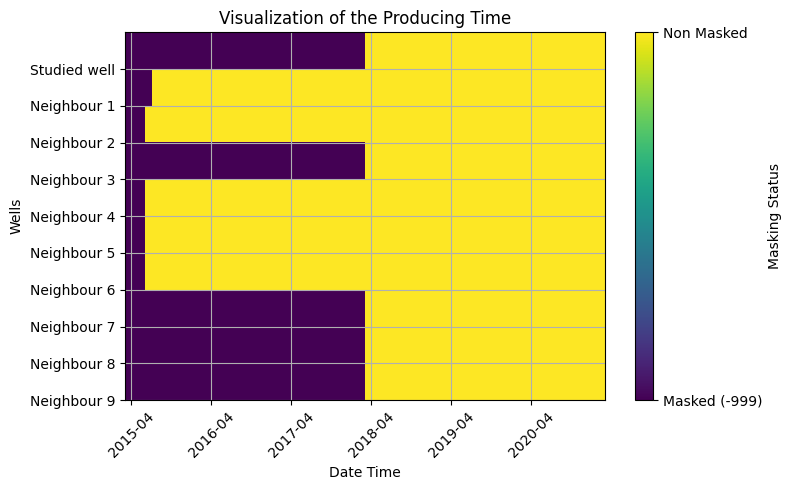

[2018    4]


In [ ]:
def plot_gfe_dynamic_input(gfe_dynamic_input, start_year, start_month):
    num_elements, num_timesteps, num_features = gfe_dynamic_input.shape

    # Generate a time axis centered around the start year and start month
    start_date = pd.Timestamp(year=start_year, month=start_month, day=1)
    hist_date = start_date - pd.DateOffset(months=num_timesteps // 2)  # last month in hist
    end_date = start_date + pd.DateOffset(months=num_timesteps // 2)  # last month in hist

    time_range = pd.date_range(start=hist_date,end=end_date,periods=num_timesteps)

    # Prepare the data for plotting
    feature_0_data = gfe_dynamic_input[:, :, 0]  # Focus on feature 0

    fig, ax = plt.subplots(figsize=(8, 5))
    cax = ax.imshow(feature_0_data, aspect='auto', cmap='viridis', extent=[time_range[0], time_range[-1], 0, num_elements])

    # Set the x-axis to the time range
    ax.set_xticks(pd.date_range(start=time_range[0], end=time_range[-1], freq='12M'))
    ax.set_xticklabels(pd.date_range(start=time_range[0], end=time_range[-1], freq='12M').strftime('%Y-%m'))
    plt.xticks(rotation=45)

    # Set the y-axis
    ax.set_yticks(np.arange(num_elements - 1, -1, -1))
    ax.set_yticklabels(['Studied well' if i == 0 else f'Neighbour {i}' for i in range(num_elements)])

    # Set labels
    ax.set_xlabel('Date Time')
    ax.set_ylabel('Wells')
    ax.set_title('Visualization of the Producing Time')
    ax.grid()

    # Add a colorbar
    cbar = fig.colorbar(cax, ax=ax, ticks=[-999, 0], orientation='vertical')
    cbar.ax.set_yticklabels(['Masked (-999)', 'Non Masked'])
    cbar.set_label('Masking Status')

    plt.tight_layout()
    plt.show()

# Example usage
plot_case = 18
print(np.where(cluster_labels == cluster_labels[plot_case])[0])
plot_gfe_dynamic_input(gfe_dynamic_inputs[plot_case][:,:,[4]], start_dates[plot_case][0], start_dates[plot_case][1])
print(start_dates[plot_case])


[2018    4]
(10, 72, 7)


(-500.0, 11000.0)

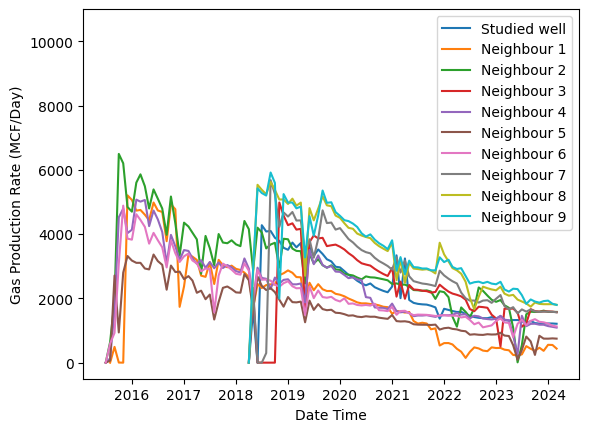

In [ ]:
clust_n = plot_case
cluster_wells = np.where(cluster_labels == cluster_labels[clust_n])[0]
well_names = [list(grouped_train.groups.keys())[i] for i in cluster_wells]
for i, well in enumerate(well_names):
  if i == 0:
    well_lable = 'Studied well'
  else:
    well_lable = f'Neighbour {i}'
  dftest = grouped_train.get_group(well).reset_index(drop=True)
  dftest['ProducingMonth'] = pd.to_datetime(dftest['ProducingMonth'])
  plt.plot(dftest['ProducingMonth'],dftest['CDGas_MCFPerDAY'],label=f'{well_lable}')

plt.legend()
plt.xlabel('Date Time')
plt.ylabel('Gas Production Rate (MCF/Day)')
print(start_dates[clust_n])
print(gfe_dynamic_inputs[clust_n].shape)
plt.ylim([-500,11000])

## 2.2 Sequence Segmentation for Real-Time Updating

In [ ]:
def nan_padding_end(sub_list,max_length):
    padded_array = np.empty((sub_list.shape[0], max_length,sub_list.shape[2]))
    padded_array[:] = np.nan
    current_t = sub_list.shape[1]
    padded_array[:,:current_t,:] = sub_list

    return padded_array

def MED_graph_segmentation(train_arr,m,max_len):
    train_arr = train_arr[:,:m,:]
    en_processed = nan_padding_end(train_arr,max_len)
    return en_processed

def Graph_padding(en_DU, en_SS, adj_matrix,node_max):
    node_count, sequence_length, feature_dim_DU = en_DU.shape
    node_count_SS, feature_dim_SS = en_SS.shape
    _, _, node_count_adj = adj_matrix.shape

    if node_count >= node_max:
        # No padding needed if the current node count is already >= node_max
        return en_DU, en_SS, adj_matrix

    # Create the padded en_DU
    padded_en_DU = np.zeros((node_max, sequence_length, feature_dim_DU))
    padded_en_DU[:node_count, :, :] = en_DU

    # Create the padded en_SS
    padded_en_SS = np.zeros((node_max, feature_dim_SS))
    padded_en_SS[:node_count_SS, :] = en_SS

    # Create the padded adj_matrix
    padded_adj_matrix = np.zeros((node_max, sequence_length, node_max))
    padded_adj_matrix[:node_count, :, :node_count_adj] = adj_matrix

    return padded_en_DU, padded_en_SS, padded_adj_matrix

def nan_padding_start(sub_list,max_length):
    padded_array = np.empty((max_length,sub_list.shape[1]))
    padded_array2 = np.empty((max_length,sub_list.shape[1]))
    padded_array[:] = np.nan
    padded_array2[:] = np.nan
    current_t = max_length-sub_list.shape[0]
    padded_array[current_t:,:] = sub_list
    new_array = np.concatenate((padded_array2,padded_array),axis=0)
    return new_array

def nan_padding_end2(sub_list,max_length):
    padded_array = np.empty((max_length,sub_list.shape[1]))
    padded_array[:] = np.nan
    current_t = sub_list.shape[0]
    padded_array[:current_t,:] = sub_list

    return padded_array

# Data segmentation and padding
def MED_segmentation(train_df,m,max_len):
    m-=36
    half_max = int(max_len/2)

    en_trainx = np.array(train_df[dynamic_feature_list+ARterms_list].iloc[:m])# out_list is modified to ARlist
    en_trainx = nan_padding_end2(en_trainx, half_max)
    en_trainx_padded = nan_padding_start(en_trainx, half_max)

    de_trainx = np.array(train_df[DS_list].iloc[m:half_max])
    de_trainx_padded = nan_padding_start(de_trainx, half_max)

    output_val = np.array(train_df['DenoisedGasRate'].iloc[m:half_max])
    output_val = output_val.reshape(-1, 1)
    output_padded = nan_padding_start(output_val, half_max)
    return en_trainx_padded,de_trainx_padded, output_padded

In [ ]:
n = 0
for i in range(len(gfe_dynamic_inputs)):
  if gfe_dynamic_inputs[i].shape[0]>n:
    n = gfe_dynamic_inputs[i].shape[0]
    i_appear = i
print(f'largest node number:{n} at {i_appear}')

largest node number:28 at 48


In [ ]:
en_du_inputs = []
en_s_inputs = []
en_adj = []
en_du_scsc = []
de_inputs = []
de_outputs = []
max_len = 72
node_max = 28
train_well_names = list(grouped_train_norm.groups.keys())

# segment_len = list(range(36,46)) # Segmentation for real-time updating
segment_len = [36,41,46]
for i in range(len(gfe_dynamic_inputs)):
    grouped_train_i = grouped_train_norm.get_group(train_well_names[i]).reset_index(drop=True)
    for m in segment_len:
        gfe_du_i = gfe_dynamic_inputs[i]
        gfe_s_i = gfe_static_inputs[i]
        adj_i = adj_matrix[i]
        en_processed = MED_graph_segmentation(gfe_du_i,m,max_len)
        en_du_in, en_s_in, adj_processed = Graph_padding(en_processed, gfe_s_i, adj_i, node_max)
        en_du_sc, de_in_processed, out_processed = MED_segmentation(grouped_train_i,m,max_len)

        en_du_inputs.append(en_du_in)
        en_s_inputs.append(en_s_in)
        en_adj.append(adj_processed)
        en_du_scsc.append(en_du_sc)
        de_inputs.append(de_in_processed)
        de_outputs.append(out_processed)

In [ ]:
en_du_inputs = np.array(en_du_inputs)
en_s_inputs = np.array(en_s_inputs)
en_adj = np.array(en_adj)
en_du_scsc = np.array(en_du_scsc)
de_inputs = np.array(de_inputs)
de_outputs = np.array(de_outputs)
print(f'encoder DU input shape {en_du_inputs.shape}')
print(f'encoder S input shape {en_s_inputs.shape}')
print(f'encoder adj input shape {en_adj.shape}')
print(f'encoder skip connect input shape {en_du_scsc.shape}')
print(f'decoder input shape {de_inputs.shape}')
print(f'output shape {de_outputs.shape}')

encoder DU input shape (7935, 28, 72, 7)
encoder S input shape (7935, 28, 34)
encoder adj input shape (7935, 28, 72, 28)
encoder skip connect input shape (7935, 72, 7)
decoder input shape (7935, 72, 38)
output shape (7935, 72, 1)


In [ ]:
en_du_inputs_pad = np.nan_to_num(en_du_inputs, nan=pad_value)
en_du_scsc_pad = np.nan_to_num(en_du_scsc,nan = pad_value)
de_inputs_pad = np.nan_to_num(de_inputs , nan=pad_value)
de_outputs_pad = np.nan_to_num(de_outputs , nan=pad_value)

# 3. Build the Neural Netowrk
## 3.1 Define the Model

In [ ]:
class GraphConvolution(Layer):
    def __init__(self, output_dim, use_bias=True, **kwargs):
        super(GraphConvolution, self).__init__(**kwargs)
        self.output_dim = output_dim
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[0][-1]  # Updated to correctly capture input feature dimension
        self.kernel = self.add_weight(shape=(input_dim, self.output_dim),
                                      initializer='glorot_uniform',
                                      trainable=True,
                                      name='kernel')
        if self.use_bias:
            self.bias = self.add_weight(shape=(self.output_dim,),
                                        initializer='zeros',
                                        trainable=True,
                                        name='bias')
        super(GraphConvolution, self).build(input_shape)

    def call(self, inputs):
        features, adj_matrix = inputs
        adj_norm = self.normalize_adj(adj_matrix)
        output = tf.matmul(adj_norm, features)
        output = tf.matmul(output, self.kernel)
        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)
        return output

    def normalize_adj(self, adj):
        rowsum = tf.reduce_sum(adj, axis=-1)
        d_inv_sqrt = tf.pow(rowsum, -0.5)
        d_inv_sqrt = tf.where(tf.math.is_inf(d_inv_sqrt), tf.zeros_like(d_inv_sqrt), d_inv_sqrt)
        d_mat_inv_sqrt = tf.linalg.diag(d_inv_sqrt)
        return tf.matmul(tf.matmul(d_mat_inv_sqrt, adj), d_mat_inv_sqrt)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.output_dim)

    def get_config(self):
        config = super(GraphConvolution, self).get_config()
        config.update({
            'output_dim': self.output_dim,
            'use_bias': self.use_bias,
        })
        return config


In [ ]:
class CustomGRUCell(Layer):
    def __init__(self, units):
        super(CustomGRUCell, self).__init__()
        self.units = units
        self.state_size = units

    def build(self, input_shape):
        self.Wz = self.add_weight(shape=(input_shape[-1] + self.units, self.units), initializer='glorot_uniform', name='Wz')
        self.Wr = self.add_weight(shape=(input_shape[-1] + self.units, self.units), initializer='glorot_uniform', name='Wr')
        self.W = self.add_weight(shape=(input_shape[-1] + self.units, self.units), initializer='glorot_uniform', name='W')

        self.bz = self.add_weight(shape=(self.units,), initializer='zeros', name='bz')
        self.br = self.add_weight(shape=(self.units,), initializer='zeros', name='br')
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', name='b')

    def call(self, inputs, states):
        prev_state = states[0]
        x_h = tf.concat([inputs, prev_state], axis=1)

        z = tf.sigmoid(tf.matmul(x_h, self.Wz) + self.bz)
        r = tf.sigmoid(tf.matmul(x_h, self.Wr) + self.br)
        h_candidate = tf.tanh(tf.matmul(tf.concat([inputs, r * prev_state], axis=1), self.W) + self.b)

        new_state = (1 - z) * prev_state + z * h_candidate
        return new_state, [new_state]

In [ ]:
class STGFE(Layer):
    def __init__(self, GRU_units, GCN_units=64, GCN_layer=2, return_sequences=False, return_state=False):
        super(STGFE, self).__init__()
        self.units = GRU_units
        self.return_sequences = return_sequences
        self.return_state = return_state
        self.GCN_layer = GCN_layer
        self.gcn = GraphConvolution(output_dim = GCN_units)
        self.gru_cell = CustomGRUCell(GRU_units)

    @tf.function
    def call(self, inputs, initial_state=None):
        DU_inputs, S_inputs, adj_inputs = inputs  # Unpack inputs
        batch_size = tf.shape(DU_inputs)[0]
        num_timesteps = tf.shape(DU_inputs)[2] # shape [batch, node, seq, feat]

        if initial_state is None:
            hidden_state = tf.zeros((batch_size, self.units))
        else:
            hidden_state = initial_state

        all_hidden_states = tf.TensorArray(dtype=tf.float32, size=num_timesteps)

        gcn_embed_t = tf.TensorArray(dtype=tf.float32, size=num_timesteps)

        for t in tf.range(num_timesteps):
            x_t_du = DU_inputs[:, :, t, :]  # Dynamic unit input at time step t
            x_t = tf.concat([x_t_du, S_inputs], axis=-1)  # Concatenate DU and static inputs
            x_t_adj = adj_inputs[:, :, t, :]  # Adjacency matrix at time step t

            x_t = self.gcn([x_t, x_t_adj])

            gcn_embed = GlobalAveragePooling1D()(x_t)
            gcn_embed_t = gcn_embed_t.write(t, gcn_embed)
            hidden_state, _ = self.gru_cell(gcn_embed, [hidden_state])

            if self.return_sequences:
                all_hidden_states = all_hidden_states.write(t, hidden_state)

        gcn_embed_t = tf.transpose(gcn_embed_t.stack(), [1, 0, 2])
        if self.return_sequences:
            outputs = tf.transpose(all_hidden_states.stack(), [1, 0, 2])
        else:
            outputs = hidden_state

        if self.return_state:
            return outputs, hidden_state, gcn_embed_t
        else:
            return outputs, gcn_embed_t

In [ ]:
class WeightedSum(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(WeightedSum, self).__init__(**kwargs)

    def build(self, input_shape):
        # Create trainable weights for the layer
        self.weight_gfe = self.add_weight(name='weight_gfe',
                                          shape=(input_shape[0][-1],),
                                          initializer='ones',
                                          trainable=True)
        self.weight_gru = self.add_weight(name='weight_gru',
                                          shape=(input_shape[1][-1],),
                                          initializer='ones',
                                          trainable=True)
        super(WeightedSum, self).build(input_shape)

    def call(self, inputs):
        state_gfe, state_gru = inputs
        weighted_gfe = state_gfe * self.weight_gfe
        weighted_gru = state_gru * self.weight_gru
        return tf.add(weighted_gfe, weighted_gru)  # Element-wise addition

## 3.2 Merge the Embeddings and Compile the Model

In [ ]:
threshold_active = 0

def thresholded_tanh(x, threshold=threshold_active):
    thresholds = tf.constant(threshold, dtype=x.dtype)
    thresholds = tf.reshape(thresholds, (1, 1, -1))
    tanh_x = tf.tanh(x)
    adjusted_tanh = (tanh_x + 1) / 2 * (1 - thresholds) + thresholds  # Scales and shifts the output
    return adjusted_tanh

def masked_loss_function(y_true, y_pred):
    mask_special_val = -999
    mask = K.cast(K.not_equal(y_true, mask_special_val), K.floatx())
    y_true_masked = y_true * mask
    y_pred_masked = y_pred * mask
    loss = K.mean(K.square(y_pred_masked - y_true_masked), axis=-1)
    return loss

In [ ]:
# Encoder1: encode the historical info of the neighboring wells, including DUS
en_DU_input = Input(shape=(en_du_inputs.shape[1],en_du_inputs.shape[2], en_du_inputs.shape[3])) # shape: [node, sequence, feature]
en_S_input = Input(shape=(en_s_inputs.shape[1],en_s_inputs.shape[2]))
en_adj_input = Input(shape=(en_adj.shape[1],en_adj.shape[2], en_adj.shape[3]))  # shape: [node, sequence, feature]
mask_en_DU_input = Masking(mask_value=pad_value)(en_DU_input)

encode1, gcn_embed_t = STGFE(GRU_units = 128, GCN_units = 128, GCN_layer = 2, return_sequences=True)([mask_en_DU_input, en_S_input, en_adj_input]) # out shape: [batch, sequence, feature]
encode1 = Dropout(0.1)(encode1)
encode2 = GRU(128, return_sequences=True)(encode1)
encode2 = Dropout(0.1)(encode2)
encode3, state_gfe = GRU(128, return_sequences=False, return_state=True)(encode2)

# Encoder2:
encoder_input = Input(shape=(en_du_scsc_pad.shape[1], en_du_scsc_pad.shape[2]))
mask_en_input = Masking(mask_value=pad_value)(encoder_input)
encoder_gru1 = GRU(128, return_sequences=True)(mask_en_input)
encoder_gru1 = Dropout(0.1)(encoder_gru1)
encoder_gru2, state_gru = GRU(128, return_sequences=False, return_state=True)(encoder_gru1)

In [ ]:
# Decoder: decoder input includes D,S data of the studied well
decoder_input = Input(shape=(de_inputs.shape[1],de_inputs.shape[2])) # shape: [batch, sequence, feature]
mask_de_input = Masking(mask_value=pad_value)(decoder_input)
state = WeightedSum()([state_gfe,state_gru])

decoder_gru1 = GRU(128, return_sequences=True)(mask_de_input, initial_state=state)
decoder_gru1 = Dropout(0.1)(decoder_gru1)
decoder_gru2 = GRU(128, return_sequences=True)(decoder_gru1, initial_state=state)
decoder_gru2 = Dropout(0.1)(decoder_gru2)
decoder_dense = Dense(64, activation='tanh')(decoder_gru2)
decoder_output = Dense(1, activation=thresholded_tanh)(decoder_dense)

# Define the model
MED_model = Model([en_DU_input, en_S_input, en_adj_input, encoder_input, decoder_input], decoder_output)
MED_model.compile(optimizer='adam', loss=masked_loss_function)
MED_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 28, 72, 7)]          0         []                            
                                                                                                  
 masking (Masking)           (None, 28, 72, 7)            0         ['input_1[0][0]']             
                                                                                                  
 input_2 (InputLayer)        [(None, 28, 34)]             0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 28, 72, 28)]         0         []                            
                                                                                              

In [ ]:
history = MED_model.fit([en_du_inputs_pad, en_s_inputs, en_adj, en_du_scsc_pad, de_inputs_pad],
                        de_outputs_pad, epochs=10, batch_size=64,
                        verbose=1)

# 4. Prediction
## 4.1 Formulate the Testing Data

In [ ]:
# MinMax normalization
scaler = MinMaxScaler()
scaler = scaler.fit(training_data[all_columns_to_normalize])

all_data_norm = df.copy()
all_data_norm[all_columns_to_normalize] = scaler.transform(df[all_columns_to_normalize])

# Group by 'API_UWI' for further processing
grouped_norm = all_data_norm.groupby('API_UWI')

In [ ]:
loc_info_all = []
for name, group in grouped_df:
  group = group.reset_index(drop=True)
  well_loc = np.array(group[['Longitude','Latitude']].iloc[0])
  loc_info_all.append(well_loc)
loc_info_all = np.array(loc_info_all)

clustering_all = DBSCAN(eps=0.001,min_samples=1).fit(loc_info_all)
cluster_labels_all = clustering_all.labels_

n = 0
testing_index = []
for name, group in grouped_df:
    if group['StartYear'].iloc[0] >= split_year:
      testing_index.append(n)
    n+=1
testing_index = np.array(testing_index)

In [ ]:
gfe_static_inputs_te = []
gfe_dynamic_inputs_te = []
adj_matrix_te = []
start_dates_te = []
max_distance = 0.005  # The maximum distance threshold
max_len = 36
pad_value = -999

for well_i in testing_index:
    cluster_wells = np.where(cluster_labels_all == cluster_labels_all[well_i])[0]
    well_names = [list(grouped_norm.groups.keys())[i] for i in cluster_wells]

    gfe_static_input = []
    gfe_dynamic_input = []
    well_locs = []
    name_ii = list(grouped_norm.groups.keys())[well_i]
    #print(f"Studied: {name_ii}")
    df_well = grouped_df.get_group(name_ii).reset_index(drop=True)
    df_well_norm = grouped_norm.get_group(name_ii).reset_index(drop=True)
    gfe_output = np.array(df_well_norm[out_list])

    # Find the starting time of the studied well
    start_year = int(df_well['Year'][0])
    start_month = int(df_well['Month'][0])
    start_date = pd.Timestamp(year=start_year, month=start_month, day=1)
    start_dates_te.append([start_year, start_month])

    for name_i in well_names:
        #print(f"neighbor: {name_i}")
        df_well = grouped_df.get_group(name_i).reset_index(drop=True)
        df_well_norm = grouped_norm.get_group(name_i).reset_index(drop=True)
        input_static_norm = np.array(df_well_norm[static_feature_list].iloc[0])

        # Find the starting time of the neighboring well
        start_year_adj = int(df_well['Year'][0])
        start_month_adj = int(df_well['Month'][0])
        start_date_adj = pd.Timestamp(year=start_year_adj, month=start_month_adj, day=1)

        df_sequence = df_well_norm[DU_list]

        if start_date_adj <= start_date:
            # Sequentially search the starting month of the neighboring wells
            for time_i in range(len(df_well)):
                if df_well['Year'][time_i] == start_year and df_well['Month'][time_i] == start_month:
                    #print(f"+Ealier, start time offset: {time_i}")
                    break
            hist_data = np.array(df_sequence[:time_i])  # Include up to and including time_i
            future_data = np.array(df_sequence[time_i:])  # Start after time_i
            hist_data = trim_hist(hist_data, max_len, pad_value)
            future_data = trim_future(future_data, max_len, pad_value)
            input_dynamic_norm = np.concatenate((hist_data, future_data), axis=0)
        else:
            # Calculate the time difference in months
            time_difference = (start_date.year - start_date_adj.year) * 12 + start_date.month - start_date_adj.month
            #print(f"-Later, start time offset: {time_difference}")
            hist_data = np.zeros((max_len, df_sequence.shape[1]))+pad_value  # Pad with zeros for historical data
            trim_len = max_len+time_difference
            future_data = np.array(df_sequence[:trim_len])
            future_data = trim_hist(future_data, max_len, pad_value)  # Pad the time before production
            input_dynamic_norm = np.concatenate((hist_data, future_data), axis=0)

        input_dynamic_norm = np.nan_to_num(input_dynamic_norm , nan=pad_value)
        gfe_dynamic_input.append(input_dynamic_norm)
        gfe_static_input.append(input_static_norm)
        location = np.array(df_well[['Longitude', 'Latitude']].iloc[0])
        well_locs.append(location)

    dist_matrix = cdist(well_locs, well_locs, metric='euclidean')
    normalized_dist_matrix = min_max_normalize(dist_matrix, max_distance)
    adj = distance_to_adjacency(normalized_dist_matrix)
    dynamic_adj = create_dynamic_adj_matrix(adj,np.array(gfe_dynamic_input),pad_value)

    gfe_dynamic_inputs_te.append(np.array(gfe_dynamic_input))
    gfe_static_inputs_te.append(np.array(gfe_static_input))
    adj_matrix_te.append(dynamic_adj)
    #print("===================")

start_dates_te = np.array(start_dates_te)

477
Number of wells: 5
[2014    8]


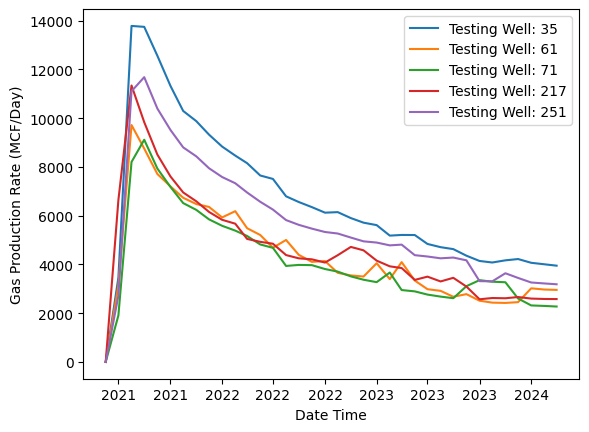

In [ ]:
from matplotlib.dates import DateFormatter
clust_n = testing_index[60]
print(clust_n)

cluster_wells = np.where(cluster_labels_all == cluster_labels_all[clust_n])[0]
well_names = [list(grouped_df.groups.keys())[i] for i in cluster_wells]

for i in well_names:
    if i in grouped_train.groups.keys():
        label_num = np.where(np.array(list(grouped_train.groups.keys())) == i)[0][0]
        label_name = 'Training Well: '+str(label_num+1)
    else:
        label_num = np.where(np.array(list(grouped_test.groups.keys())) == i)[0][0]
        label_name = 'Testing Well: '+str(label_num+1)

    dftest = grouped_df.get_group(i).reset_index(drop=True)
    dftest['ProducingMonth'] = pd.to_datetime(dftest['ProducingMonth'])
    plt.plot(dftest['ProducingMonth'], dftest['CDGas_MCFPerDAY'], label=f'{label_name}')

print(f'Number of wells: {len(well_names)}')
plt.legend()
plt.xlabel('Date Time')
plt.ylabel('Gas Production Rate (MCF/Day)')
date_form = DateFormatter("%Y")
plt.gca().xaxis.set_major_formatter(date_form)

print(start_dates[clust_n])

In [ ]:
print(gfe_dynamic_inputs_te[0].shape)
print(gfe_static_inputs_te[0].shape)
print(adj_matrix_te[0].shape)
n = 0
for i in range(len(gfe_dynamic_inputs_te)):
  if gfe_dynamic_inputs_te[i].shape[0]>n:
    n = gfe_dynamic_inputs_te[i].shape[0]
    i_appear = i
print(f'largest node number:{n} at {i_appear}')

(8, 72, 7)
(8, 34)
(8, 72, 8)
largest node number:27 at 14


In [ ]:
en_du_inputs_te = []
en_s_inputs_te = []
en_adj_te = []
en_du_scsc_te = []
de_inputs_te = []
de_outputs_te = []
max_len = 72
node_max = 28
test_well_names = list(grouped_test_norm.groups.keys())

for i in range(len(gfe_dynamic_inputs_te)):
    grouped_train_i = grouped_test_norm.get_group(test_well_names[i]).reset_index(drop=True)
    for m in segment_len:
        gfe_du_i = gfe_dynamic_inputs_te[i]
        gfe_s_i = gfe_static_inputs_te[i]
        adj_i = adj_matrix_te[i]
        en_processed = MED_graph_segmentation(gfe_du_i,m,max_len)
        en_du_in, en_s_in, adj_processed = Graph_padding(en_processed, gfe_s_i, adj_i, node_max)
        en_du_sc, de_in_processed, out_processed = MED_segmentation(grouped_train_i,m,max_len)

        en_du_inputs_te.append(en_du_in)
        en_s_inputs_te.append(en_s_in)
        en_adj_te.append(adj_processed)
        en_du_scsc_te.append(en_du_sc)
        de_inputs_te.append(de_in_processed)
        de_outputs_te.append(out_processed)

en_du_inputs_te = np.array(en_du_inputs_te)
en_s_inputs_te = np.array(en_s_inputs_te)
en_adj_te = np.array(en_adj_te)
en_du_scsc_te = np.array(en_du_scsc_te)
de_inputs_te = np.array(de_inputs_te)
de_outputs_te = np.array(de_outputs_te)

print(f'encoder DU input shape {en_du_inputs_te.shape}')
print(f'encoder S input shape {en_s_inputs_te.shape}')
print(f'encoder adj input shape {en_adj_te.shape}')
print(f'encoder skip connect input shape {en_du_scsc_te.shape}')
print(f'decoder input shape {de_inputs_te.shape}')
print(f'output shape {de_outputs_te.shape}')

en_du_inputs_pad_te = np.nan_to_num(en_du_inputs_te, nan=pad_value)
en_du_scsc_pad_te = np.nan_to_num(en_du_scsc_te, nan=pad_value)
de_inputs_pad_te = np.nan_to_num(de_inputs_te , nan=pad_value)
de_outputs_pad_te = np.nan_to_num(de_outputs_te , nan=pad_value)

encoder DU input shape (1236, 28, 72, 7)
encoder S input shape (1236, 28, 34)
encoder adj input shape (1236, 28, 72, 28)
encoder skip connect input shape (1236, 72, 7)
decoder input shape (1236, 72, 38)
output shape (1236, 72, 1)


## 4.2 Testing Results

In [ ]:
y_pred = MED_model.predict([en_du_inputs_pad_te, en_s_inputs_te, en_adj_te, en_du_scsc_pad_te, de_inputs_pad_te])

test_well_names = list(grouped_df.groups.keys())
test_well_names = [test_well_names[i] for i in testing_index]
test_label = []
time_label = []
for i in test_well_names:
    test_label.append(np.array(grouped_df.get_group(i).reset_index(drop=True)['CDGas_MCFPerDAY']))
    time_label.append(pd.to_datetime(grouped_df.get_group(i).reset_index(drop=True)['ProducingMonth']))

39/39 [==============================] - 3s 66ms/step


In [ ]:
scaler = MinMaxScaler()
scaler.fit(training_data[out_list])
y_pred_recover = np.exp(y_pred)-1
y_pred_org = scaler.inverse_transform(y_pred_recover.reshape(-1,1))
y_pred_org = y_pred_org.reshape(y_pred.shape)
# the original data was scaled by log(minmaxscale(x))+1

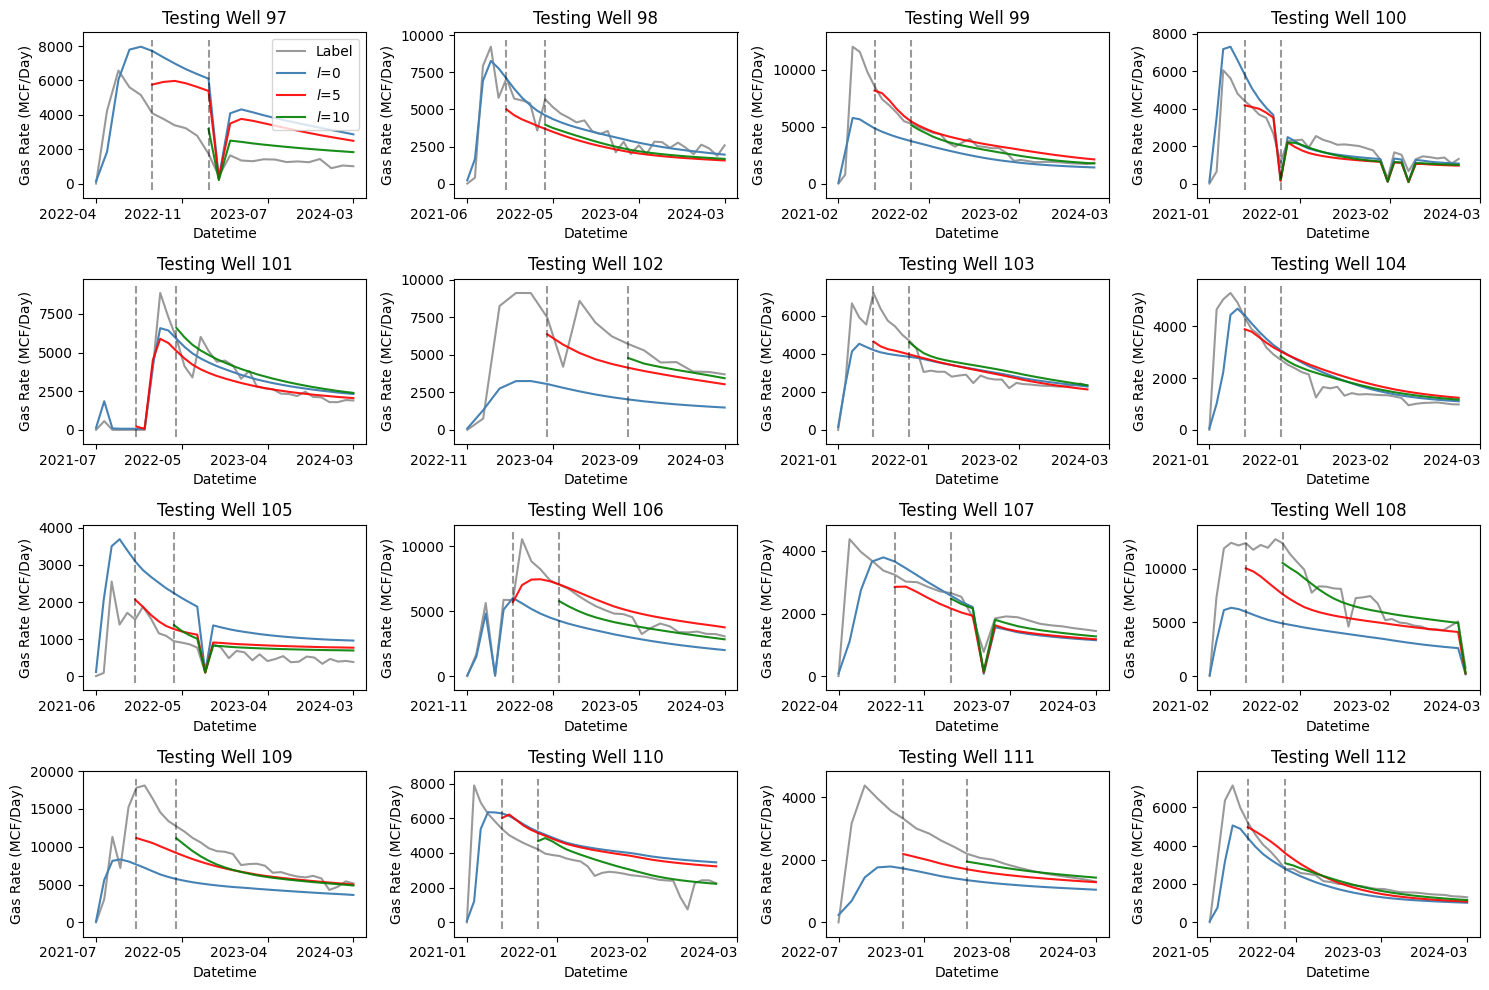

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(15, 10))  # Adjusted figsize for better fit
axes = axes.flatten()  # Flatten the axes array for easier iteration

nn = 0
for plot_num, ax in enumerate(axes):
    plot_num += 96
    time_label_dt = time_label[plot_num]

    if plot_num * 3 < y_pred_org.shape[0]:
        prod_len = len(time_label_dt) + 36

        ax.plot(time_label_dt[:36], test_label[plot_num][:36], 'k', alpha=0.4, label='Label')
        ax.plot(time_label_dt[:36], y_pred_org[plot_num * 3, 36:prod_len, :],color='steelblue', alpha=1, label='$l$=0')

        ylim = ax.get_ylim()
        ax.plot(time_label_dt[5:36], y_pred_org[plot_num * 3 + 1, 41:prod_len, :], 'r', alpha=0.9, markersize=3, label='$l$=5')
        ax.plot([time_label_dt[5],time_label_dt[5]],ylim,'--k', alpha=0.4)

        ax.plot(time_label_dt[10:36], y_pred_org[plot_num * 3 + 2, 46:prod_len, :], 'g', alpha=0.9, markersize=4, label='$l$=10')
        ax.plot([time_label_dt[10],time_label_dt[10]],ylim,'--k', alpha=0.4)

        ax.set_xlabel('Datetime')
        ax.set_ylabel('Gas Rate (MCF/Day)')

        if nn == 0 :
          ax.legend(fontsize=10)

        ax.set_title(f'Testing Well {plot_num + 1}')

        # Set x-ticks to include first, last and 5 evenly spaced datetimes in between
        first_date = time_label_dt[0]
        last_date = time_label_dt[len(time_label_dt)-1]

        # Generate 5 dates between the first and last date
        n_dt = 3
        new_ticks = [first_date + (last_date - first_date) * i / n_dt  for i in range(n_dt +1)]

        ax.set_xticks(new_ticks)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        plt.setp(ax.get_xticklabels(), rotation=0, ha='right')

    nn+=1

plt.tight_layout()
plt.show()